In [77]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'try_ts')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [78]:
df = pd.read_parquet(os.path.join(DATA_PATH, 'temperature_readings_IOT_devices', 'IOT-temp.parquet'))
df

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In
...,...,...,...,...,...
97601,__export__.temp_log_91076_7fbd08ca,Room Admin,28-07-2018 07:07,31,In
97602,__export__.temp_log_147733_62c03f31,Room Admin,28-07-2018 07:07,31,In
97603,__export__.temp_log_100386_84093a68,Room Admin,28-07-2018 07:06,31,In
97604,__export__.temp_log_123297_4d8e690b,Room Admin,28-07-2018 07:06,31,In


In [79]:
df.drop(columns=['id', 'room_id/id', 'out/in'], inplace=True)

In [80]:
df = df[~df.duplicated()]
df

,noted_date,temp
0,08-12-2018 09:30,29
2,08-12-2018 09:29,41
4,08-12-2018 09:29,31
6,08-12-2018 09:28,29
8,08-12-2018 09:26,29
...,...,...
97570,28-07-2018 07:09,33
97571,28-07-2018 07:08,31
97576,28-07-2018 07:07,31
97579,28-07-2018 07:07,32


In [81]:
df.set_index('noted_date', inplace=True)
df.index = pd.to_datetime(df.index, format='%d-%m-%Y %H:%M')
df

,temp
noted_date,
2018-12-08 09:30:00,29
2018-12-08 09:29:00,41
2018-12-08 09:29:00,31
2018-12-08 09:28:00,29
2018-12-08 09:26:00,29
...,...
2018-07-28 07:09:00,33
2018-07-28 07:08:00,31
2018-07-28 07:07:00,31


In [82]:
nan_counts = df.isna().sum()
print((nan_counts/len(df))*100)

temp    0.0
dtype: float64


In [83]:
df.nunique()

temp    31
dtype: int64

In [84]:
df = df[~df.index.duplicated()]

In [85]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp,27920.0,37.55265,6.231596,21.0,32.0,38.0,43.0,51.0


In [86]:
df

,temp
noted_date,
2018-12-08 09:30:00,29
2018-12-08 09:29:00,41
2018-12-08 09:28:00,29
2018-12-08 09:26:00,29
2018-12-08 09:25:00,42
...,...
2018-07-28 07:10:00,31
2018-07-28 07:09:00,32
2018-07-28 07:08:00,31


In [87]:
# Asegurar que el índice esté en orden ascendente
df = df.sort_index()

# Calcular la diferencia temporal y la frecuencia más común
time_diffs = df.index.to_series().diff().dropna()
most_common_freq = time_diffs.mode()[0]

# Si la frecuencia no es constante, reindexar el DataFrame
if not (time_diffs == most_common_freq).all():
    # Crear un nuevo rango de fechas con la frecuencia más común (positiva)
    new_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq=abs(most_common_freq))
    df = df.reindex(new_index)
    print("El índice ha sido reindexado para asegurar una frecuencia temporal constante.")
else:
    print("La frecuencia temporal ya es constante.")
df

El índice ha sido reindexado para asegurar una frecuencia temporal constante.


,temp
2018-07-28 07:06:00,31.0
2018-07-28 07:08:00,31.0
2018-07-28 07:10:00,31.0
2018-07-28 07:12:00,NaN
2018-07-28 07:14:00,32.0
...,...
2018-12-08 09:22:00,29.0
2018-12-08 09:24:00,29.0
2018-12-08 09:26:00,29.0
2018-12-08 09:28:00,29.0


In [88]:
df.isna().sum()

temp    81227
dtype: int64

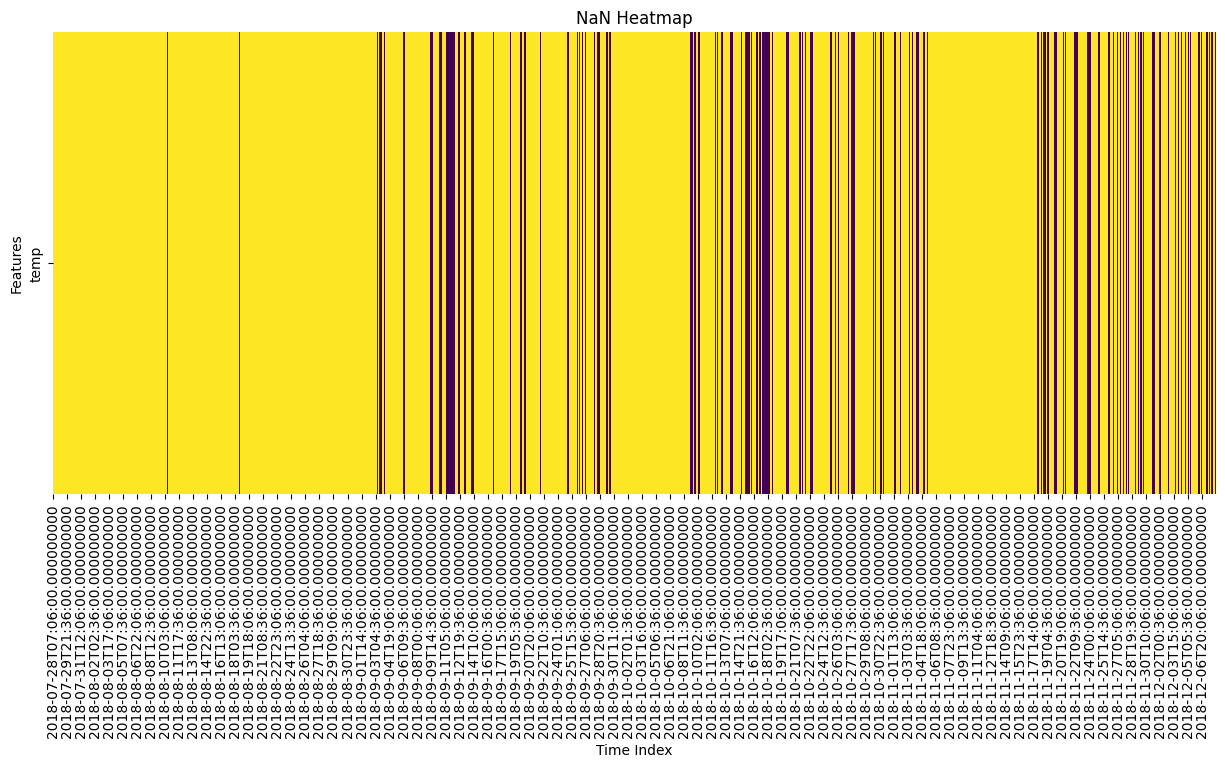

In [89]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.heatmap(df.isna().T, cmap="viridis", cbar=False)
plt.title("NaN Heatmap")
plt.xlabel("Time Index")
plt.ylabel("Features")
plt.show()

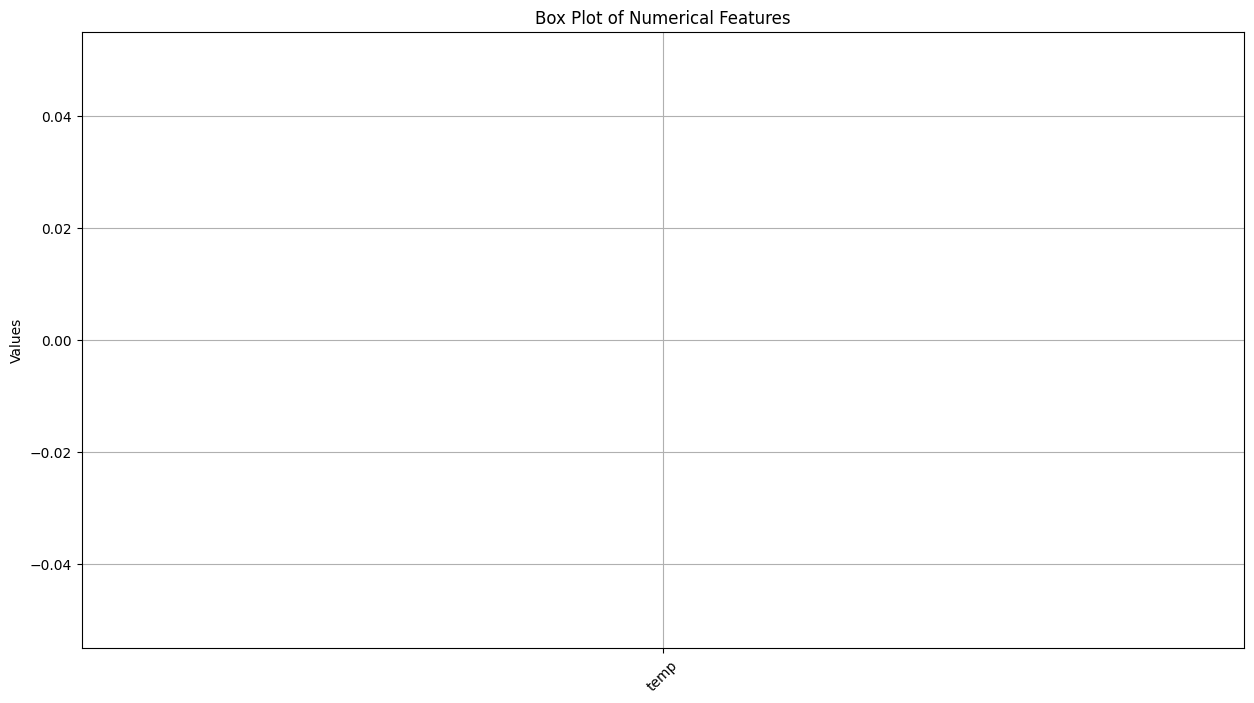

In [74]:
# Create a box plot for all numerical columns in the DataFrame
df.boxplot(figsize=(15, 8), rot=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [43]:
# Calcular el número de outliers para cada columna numérica
outliers_percentage = {}
for column in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_percentage[column] = f'{round(((df[column] < lower_bound) | (df[column] > upper_bound)).sum()/len(df) * 100, 4)} %'

# Mostrar el número de outliers por columna
outliers_percentage

{'temp': '0.0 %'}

In [ ]:
df['y'] = df['Dissolved_Oxygen_mg_L']
df.drop(columns=['Dissolved_Oxygen_mg_L'], inplace=True)

In [ ]:
df.to_parquet(os.path.join(DATA_PATH, 'DWLR', 'clean.parquet'))